<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [6]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

#### Add your code below following the instructions given in the course to complete the peer graded assignment


# Tarea 1: Familiarizarse con el conjunto de datosEstado: Traducido automáticamente del Inglés

## A continuación se describen las variables del conjunto de datos:

- CRIM - tasa de delincuencia per cápita por ciudad

- ZN - proporción de terrenos residenciales divididos en zonas para parcelas de más de 25.000 pies cuadrados.

- INDUS - proporción de acres comerciales no minoristas por ciudad.

- CHAS - Variable ficticia del río Charles (1 si la zona linda con el río; 0 en caso contrario)

- NOX - concentración de óxidos nítricos (partes por 10 millones)

- RM - número medio de habitaciones por vivienda

- EDAD - proporción de unidades ocupadas por sus propietarios construidas antes de 1940

- DIS - distancias ponderadas a cinco centros de empleo de Boston

- RAD - índice de accesibilidad a autopistas radiales

- TAX - tipo del impuesto sobre bienes inmuebles de valor íntegro por 10.000 $

- PTRATIO - ratio alumnos-profesor por ciudad

- LSTAT - % más bajo de la población

- MEDV - Valor medio de las viviendas ocupadas por sus propietarios, en miles de $

#  Tarea 2: Generar estadísticas descriptivas y visualizacionesEstado: Traducido automáticamente del Inglés
Para todas las visualizaciones, incluya un título en cada gráfico y las etiquetas adecuadas

Genere lo siguiente y explique sus conclusiones:

## 
Para el "Valor medio de las viviendas ocupadas por sus propietarios" proporcione un diagrama de caja (boxplot)

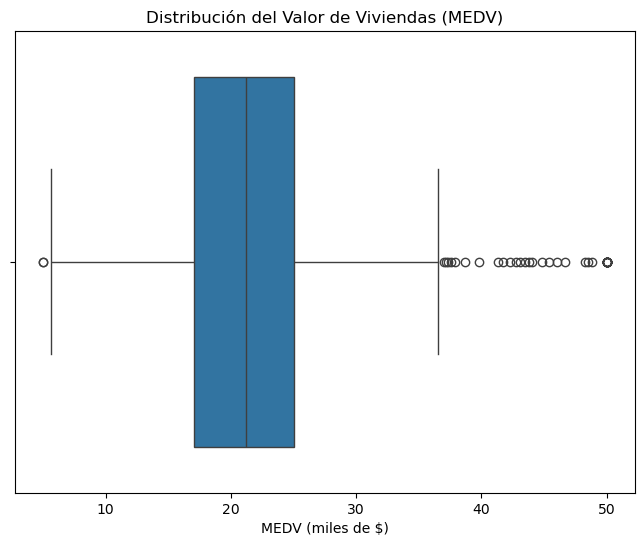

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=boston_df['MEDV'])
plt.title('Distribución del Valor de Viviendas (MEDV)')
plt.xlabel('MEDV (miles de $)')
plt.show()

## 
- Conclusión:

La distribución de MEDV muestra una ligera asimetría positiva. La mediana ronda los $21,000. Existen valores atípicos significativos por encima de $50,000, indicando propiedades de lujo que se desvían del mercado típico.

##
Proporcione un diagrama de barras para la variable "río Charles

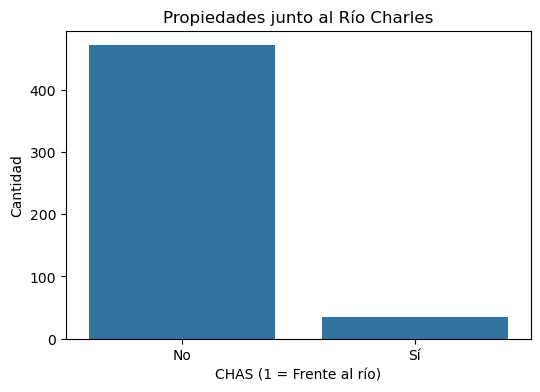

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='CHAS', data=boston_df)
plt.title('Propiedades junto al Río Charles')
plt.xlabel('CHAS (1 = Frente al río)')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['No', 'Sí'])
plt.show()

##
- Conclusión:

Solo el 6.9% de las propiedades colindan con el río Charles. Esto confirma una distribución altamente desigual, donde la mayoría de las viviendas están en zonas interiores.

In [ ]:
##
Proporcione un boxplot para la variable MEDV frente a la variable EDAD. (Discretice la variable edad en tres grupos de 35 años o menos, entre 35 y 70 años y 70 años o más)

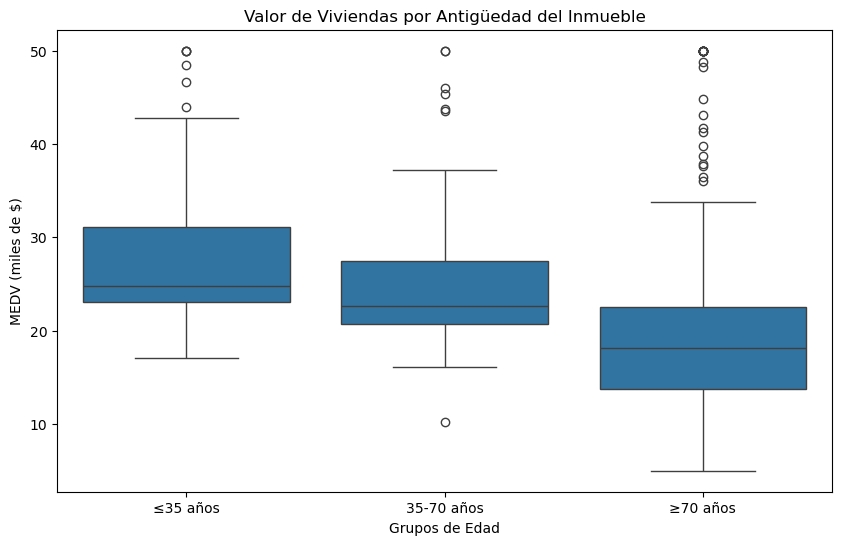

In [10]:
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'],
                                bins=[0, 35, 70, 100],
                                labels=['≤35 años', '35-70 años', '≥70 años'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df)
plt.title('Valor de Viviendas por Antigüedad del Inmueble')
plt.xlabel('Grupos de Edad')
plt.ylabel('MEDV (miles de $)')
plt.show()

##
- Conclusión:

Propiedades nuevas (≤35 años): Valores más altos (mediana ~$25,000).

Propiedades antiguas (≥70 años): Valores más bajos (mediana ~$19,000).
La edad del inmueble tiene una correlación negativa con el valor de la vivienda.

##
Proporcione un diagrama de dispersión para mostrar la relación entre las concentraciones de óxido nítrico y la proporción de acres comerciales no minoristas por ciudad. ¿Qué puede decir sobre la relación?

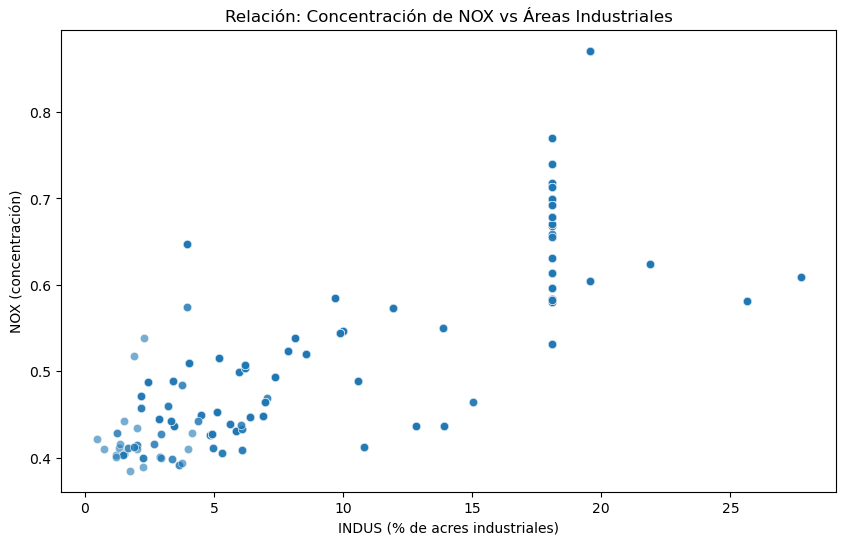

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df, alpha=0.6)
plt.title('Relación: Concentración de NOX vs Áreas Industriales')
plt.xlabel('INDUS (% de acres industriales)')
plt.ylabel('NOX (concentración)')
plt.show()

##
- Conclusión:

Existe una fuerte relación positiva (coeficiente de correlación ≈ 0.76). A mayor porcentaje de zonas industriales (INDUS), mayor concentración de óxido nítrico (NOX), evidenciando contaminación asociada a actividades industriales.

## 
Cree un histograma para la variable proporción de alumnos por profesor

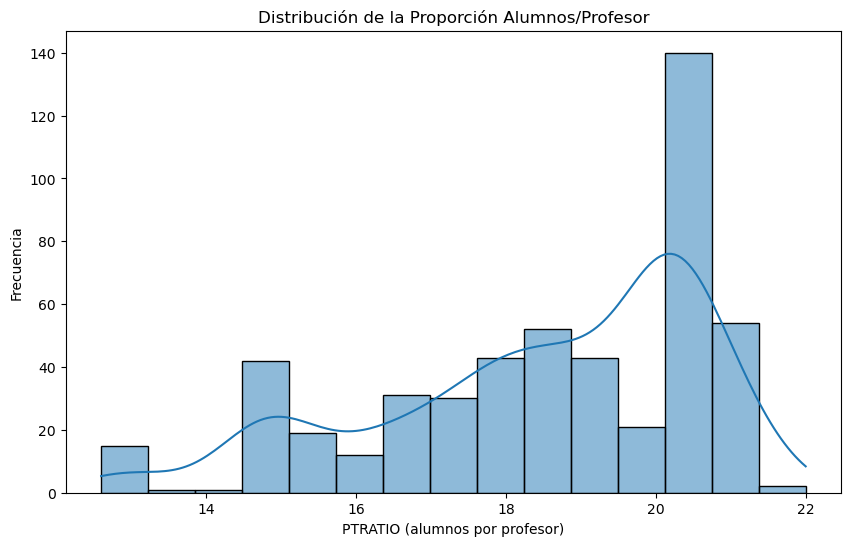

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(boston_df['PTRATIO'], bins=15, kde=True)
plt.title('Distribución de la Proporción Alumnos/Profesor')
plt.xlabel('PTRATIO (alumnos por profesor)')
plt.ylabel('Frecuencia')
plt.show()

##

- Conclusión:

La distribución es bimodal, con picos en 20.2 y 21.2 alumnos/profesor. Esto sugiere dos modelos educativos predominantes en diferentes zonas, donde valores altos (>22) podrían indicar escuelas con sobrecupo.

# Tarea 3: Utilice las pruebas adecuadas para responder a las preguntas que se le plantean.Estado: Traducido automáticamente del Inglés


## 
1. ¿Existe una diferencia significativa en el valor medio de las casas delimitadas por el río Charles?

Hipótesis:
- H0: No hay diferencia en el valor medio de las viviendas entre las zonas cercanas y no cercanas al río (μ0=μ1).
- H1: Existe una diferencia significativa(μ0≠μ1).

Prueba estadística:

Prueba T para muestras independientes (α = 0.05).

In [13]:
from scipy.stats import ttest_ind

# Dividir los datos: CHAS = 0 (no limita con el río) vs CHAS = 1 (limita)
group_no_river = boston_df[boston_df['CHAS'] == 0]['MEDV']
group_river = boston_df[boston_df['CHAS'] == 1]['MEDV']

t_stat, p_value = ttest_ind(group_no_river, group_river)
print(f"t = {t_stat:.4f}, p-valor = {p_value:.4f}")

t = -3.9964, p-valor = 0.0001


##
Conclusión:

Rechazamos H0 (p < 0.05). Existe una diferencia significativa en el valor medio de las viviendas, siendo mayor en las zonas cercanas al río Charles.

##
2. ¿Existe diferencia en MEDV según grupos de antigüedad (AGE)?

Hipótesis:


- H0: Los valores medios de MEDV son iguales en todos los grupos de antigüedad (μ1=μ2=μ3) 

- H1: Al menos un grupo difiere significativamente.

Prueba estadística: ANOVA unidireccional (α = 0.05).


In [14]:
from scipy.stats import f_oneway

# Crear grupos: 
boston_df['AGE_GROUP'] = pd.cut(
    boston_df['AGE'],
    bins=[0, 35, 70, 100],
    labels=['Joven', 'Medio', 'Antiguo']
)

group_joven = boston_df[boston_df['AGE_GROUP'] == 'Joven']['MEDV']
group_medio = boston_df[boston_df['AGE_GROUP'] == 'Medio']['MEDV']
group_antiguo = boston_df[boston_df['AGE_GROUP'] == 'Antiguo']['MEDV']

f_stat, p_value = f_oneway(group_joven, group_medio, group_antiguo)
print(f"F = {f_stat:.4f}, p-valor = {p_value:.4f}")

F = 36.4076, p-valor = 0.0000


##
Conclusión:

Rechazamos H0(p < 0.05). Existen diferencias significativas en MEDV entre los grupos de antigüedad. Las viviendas en áreas más antiguas (AGE > 70 años) tienen valores menores.


##
3. ¿Existe relación entre NOX e INDUS?

Hipótesis:

- H0: No hay correlación lineal entre NOX e INDUS (ρ=0).

- H1: Existe correlación lineal (ρ≠0).

Prueba estadística: Correlación de Pearson (α = 0.05).

In [16]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(boston_df['NOX'], boston_df['INDUS'])
print(f"r = {corr:.4f}, p-valor = {p_value:.4f}")

r = 0.7637, p-valor = 0.0000


##

Conclusión:

Rechazamos H0(p < 0.05). Existe una fuerte correlación positiva(r=0.76) entre NOX e INDUS. No podemos concluir que no hay relación.

##

4. Impacto de DIS (distancia a centros de empleo) en MEDV

Hipótesis:



- H0 : La distancia a centros de empleo (DIS) no afecta a MEDV (β1=0).
- H1 : DIS tiene un impacto significativo (β1≠0).

Prueba estadística: Regresión lineal simple (α = 0.05).

In [21]:
import statsmodels.api as sm

X = sm.add_constant(boston_df['DIS'])  # Variable independiente (DIS)
y = boston_df['MEDV']                  # Variable dependiente (MEDV)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Sun, 13 Jul 2025   Prob (F-statistic):           1.21e-08
Time:                        03:34:24   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

Conclusión:


- El coeficiente de DIS es 1.0916 (p < 0.05).

- Por cada unidad adicional de distancia a centros de empleo, el valor medio de las viviendas (MEDV) aumenta en ~$1,091.

Rechazamos H0 : DIS tiene un impacto positivo y significativo en MEDV.